Training with Backprop...
[BP] Epoch 1, Test Loss: 0.4903, Test Acc: 0.8795
[BP] Epoch 2, Test Loss: 0.3801, Test Acc: 0.8996
[BP] Epoch 3, Test Loss: 0.3360, Test Acc: 0.9103
[BP] Epoch 4, Test Loss: 0.3104, Test Acc: 0.9153
[BP] Epoch 5, Test Loss: 0.2927, Test Acc: 0.9187
[BP] Epoch 6, Test Loss: 0.2792, Test Acc: 0.9222
[BP] Epoch 7, Test Loss: 0.2681, Test Acc: 0.9244
[BP] Epoch 8, Test Loss: 0.2586, Test Acc: 0.9261
[BP] Epoch 9, Test Loss: 0.2501, Test Acc: 0.9282
[BP] Epoch 10, Test Loss: 0.2425, Test Acc: 0.9304
[BP] Epoch 11, Test Loss: 0.2355, Test Acc: 0.9332
[BP] Epoch 12, Test Loss: 0.2289, Test Acc: 0.9352
[BP] Epoch 13, Test Loss: 0.2227, Test Acc: 0.9365
[BP] Epoch 14, Test Loss: 0.2169, Test Acc: 0.9376
[BP] Epoch 15, Test Loss: 0.2114, Test Acc: 0.9389
[BP] Epoch 16, Test Loss: 0.2062, Test Acc: 0.9406
[BP] Epoch 17, Test Loss: 0.2012, Test Acc: 0.9420
[BP] Epoch 18, Test Loss: 0.1965, Test Acc: 0.9433
[BP] Epoch 19, Test Loss: 0.1920, Test Acc: 0.9445
[BP] Epoch 20,

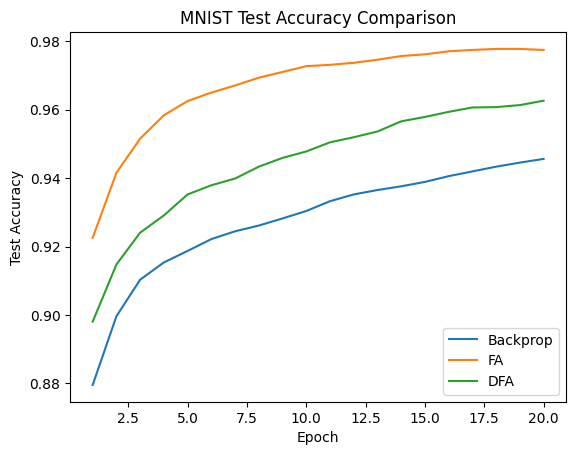

In [9]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit
import numpy as np
import tensorflow_datasets as tfds
from functools import partial
import matplotlib.pyplot as plt

# ----- Data (MNIST) -----

def load_mnist(batch_size=128):
    ds_builder = tfds.builder('mnist')
    ds_builder.download_and_prepare()
    train_ds = tfds.as_numpy(ds_builder.as_dataset(split='train', batch_size=batch_size, shuffle_files=True))
    test_ds = tfds.as_numpy(ds_builder.as_dataset(split='test', batch_size=batch_size, shuffle_files=False))

    train_batches, test_batches = [], []
    for batch in train_ds:
        x = batch['image'].astype(np.float32) / 255.0
        x = x.reshape(x.shape[0], -1)
        y = batch['label']
        train_batches.append((jnp.array(x), jnp.array(y)))
    for batch in test_ds:
        x = batch['image'].astype(np.float32) / 255.0
        x = x.reshape(x.shape[0], -1)
        y = batch['label']
        test_batches.append((jnp.array(x), jnp.array(y)))
    return train_batches, test_batches

# ----- MLP definition -----

def init_mlp(key, layer_sizes):
    params = []
    keys = random.split(key, len(layer_sizes) - 1)
    for k, (n_in, n_out) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        w = random.normal(k, (n_in, n_out)) * jnp.sqrt(2 / n_in)
        b = jnp.zeros((n_out,))
        params.append({'w': w, 'b': b})
    return params

@jit
def forward(params, x):
    a = x
    for layer in params[:-1]:
        a = jnp.tanh(jnp.dot(a, layer['w']) + layer['b'])
    logits = jnp.dot(a, params[-1]['w']) + params[-1]['b']
    return logits

@jit
def loss_fn(params, x, y):
    logits = forward(params, x)
    one_hot = jax.nn.one_hot(y, logits.shape[-1])
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1))

@jit
def accuracy_fn(params, x, y):
    logits = forward(params, x)
    preds = jnp.argmax(logits, axis=-1)
    return jnp.mean(preds == y)

# ----- Training routines -----

def train_backprop(rng, train_batches, test_batches, layer_sizes, lr=1e-2, epochs=20):
    params = init_mlp(rng, layer_sizes)
    history = {'loss': [], 'accuracy': []}

    @jit
    def sgd_step(params, x, y):
        grads = grad(loss_fn)(params, x, y)
        return [{'w': p['w'] - lr * g['w'], 'b': p['b'] - lr * g['b']} for p, g in zip(params, grads)]

    for epoch in range(epochs):
        for x, y in train_batches:
            params = sgd_step(params, x, y)
        losses = [loss_fn(params, xb, yb) for xb, yb in test_batches]
        accs = [accuracy_fn(params, xb, yb) for xb, yb in test_batches]
        history['loss'].append(np.mean(losses))
        history['accuracy'].append(np.mean(accs))
        print(f"[BP] Epoch {epoch+1}, Test Loss: {history['loss'][-1]:.4f}, Test Acc: {history['accuracy'][-1]:.4f}")
    return params, history


def train_fa(rng, train_batches, test_batches, layer_sizes, lr=1e-2, epochs=10):
    params = init_mlp(rng, layer_sizes)
    history = {'loss': [], 'accuracy': []}
    # Prepare fixed random feedback matrices for hidden layers
    num_hidden = len(layer_sizes) - 2
    keys = random.split(rng, num_hidden)
    # B_l maps error from layer l+2 to layer l+1
    Bs = [random.normal(k, (layer_sizes[l+2], layer_sizes[l+1])) for l, k in enumerate(keys)]

    @jit
    def fa_step(params, x, y):
        # Forward pass
        acts = [x]
        for layer in params[:-1]:
            acts.append(jnp.tanh(jnp.dot(acts[-1], layer['w']) + layer['b']))
        logits = jnp.dot(acts[-1], params[-1]['w']) + params[-1]['b']
        # Output error
        one_hot = jax.nn.one_hot(y, logits.shape[-1])
        delta_out = (jax.nn.softmax(logits) - one_hot) / x.shape[0]
        # Backward pass via fixed B
        deltas = [None] * len(params)
        deltas[-1] = delta_out
        # For each hidden layer l from last hidden to first
        for l in reversed(range(len(params)-1)):
            deriv = 1 - acts[l+1]**2
            deltas[l] = deriv * (deltas[l+1] @ Bs[l])
        # Update params
        new_params = []
        for l, layer in enumerate(params):
            dw = acts[l].T @ deltas[l]
            db = jnp.sum(deltas[l], axis=0)
            new_params.append({'w': layer['w'] - lr * dw, 'b': layer['b'] - lr * db})
        return new_params

    for epoch in range(epochs):
        for x, y in train_batches:
            params = fa_step(params, x, y)
        losses = [loss_fn(params, xb, yb) for xb, yb in test_batches]
        accs = [accuracy_fn(params, xb, yb) for xb, yb in test_batches]
        history['loss'].append(np.mean(losses))
        history['accuracy'].append(np.mean(accs))
        print(f"[FA] Epoch {epoch+1}, Test Loss: {history['loss'][-1]:.4f}, Test Acc: {history['accuracy'][-1]:.4f}")
    return params, history


def train_dfa(rng, train_batches, test_batches, layer_sizes, lr=1e-2, epochs=10):
    params = init_mlp(rng, layer_sizes)
    history = {'loss': [], 'accuracy': []}
    # Prepare fixed random feedback matrices direct from output to each hidden layer
    num_hidden = len(layer_sizes) - 2
    keys = random.split(rng, num_hidden)
    Bs = [random.normal(k, (layer_sizes[-1], layer_sizes[l+1])) for l, k in enumerate(keys)]

    @jit
    def dfa_step(params, x, y):
        # Forward
        acts = [x]
        for layer in params[:-1]:
            acts.append(jnp.tanh(jnp.dot(acts[-1], layer['w']) + layer['b']))
        logits = jnp.dot(acts[-1], params[-1]['w']) + params[-1]['b']
        # Output error
        one_hot = jax.nn.one_hot(y, logits.shape[-1])
        delta_out = (jax.nn.softmax(logits) - one_hot) / x.shape[0]
        # Direct feedback to hidden layers
        deltas = [None] * len(params)
        deltas[-1] = delta_out
        for l in range(len(params)-1):
            deriv = 1 - acts[l+1]**2
            deltas[l] = deriv * (delta_out @ Bs[l])
        # Update params
        new_params = []
        for l, layer in enumerate(params):
            dw = acts[l].T @ deltas[l]
            db = jnp.sum(deltas[l], axis=0)
            new_params.append({'w': layer['w'] - lr * dw, 'b': layer['b'] - lr * db})
        return new_params

    for epoch in range(epochs):
        for x, y in train_batches:
            params = dfa_step(params, x, y)
        losses = [loss_fn(params, xb, yb) for xb, yb in test_batches]
        accs = [accuracy_fn(params, xb, yb) for xb, yb in test_batches]
        history['loss'].append(np.mean(losses))
        history['accuracy'].append(np.mean(accs))
        print(f"[DFA] Epoch {epoch+1}, Test Loss: {history['loss'][-1]:.4f}, Test Acc: {history['accuracy'][-1]:.4f}")
    return params, history

# ----- Main -----
if __name__ == "__main__":
    rng = random.PRNGKey(0)
    train_batches, test_batches = load_mnist()
    layer_sizes = [28*28, 256, 128, 10]
    epochs = 20

    print("Training with Backprop...")
    _, bp_hist = train_backprop(rng, train_batches, test_batches, layer_sizes, epochs=epochs)

    print("\nTraining with Feedback Alignment (FA)...")
    _, fa_hist = train_fa(rng, train_batches, test_batches, layer_sizes, epochs=epochs)

    print("\nTraining with Direct Feedback Alignment (DFA)...")
    _, dfa_hist = train_dfa(rng, train_batches, test_batches, layer_sizes, epochs=epochs)

    # ----- Plot test accuracy over epochs -----
    epochs_list = list(range(1, epochs + 1))
    plt.figure()
    plt.plot(epochs_list, bp_hist['accuracy'], label='Backprop')
    plt.plot(epochs_list, fa_hist['accuracy'], label='FA')
    plt.plot(epochs_list, dfa_hist['accuracy'], label='DFA')
    plt.xlabel('Epoch')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.title('MNIST Test Accuracy Comparison')
    plt.show()
